In [5]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import pfhedge
from pfhedge.instruments import BrownianStock
from pfhedge.instruments import EuropeanOption

from pfhedge.nn import Hedger
from pfhedge.nn import MultiLayerPerceptron
from pfhedge.nn.functional import entropic_risk_measure
from pfhedge.nn import BlackScholes
from pfhedge.features._base import StateIndependentFeature




In [6]:
torch.manual_seed(6)
N_PATHS = 50000
N_EPOCHS = 100

In [7]:
data = pd.read_csv("IBM.csv")
data["Date"] = pd.to_datetime(data["Date"])

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13642 entries, 0 to 13641
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Unnamed: 0  13642 non-null  int64         
 1   Date        13642 non-null  datetime64[us]
 2   Open_IBM    13642 non-null  float64       
 3   High_IBM    13642 non-null  float64       
 4   Low_IBM     13642 non-null  float64       
 5   Close_IBM   13642 non-null  float64       
 6   Volume_IBM  13642 non-null  int64         
dtypes: datetime64[us](1), float64(4), int64(2)
memory usage: 746.2 KB


In [9]:
T_start = len(data)-100

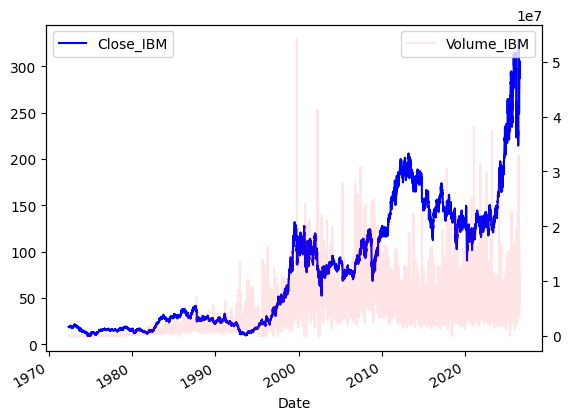

In [10]:
ax1 = data.plot(x="Date", y="Close_IBM", color="blue")
ax2 = ax1.twinx()
data.plot(x="Date", y="Volume_IBM", ax=ax2, color="red",alpha=0.1)
plt.show()

In [11]:
historical_prices = data["Close_IBM"].iloc[T_start:].copy()

s0 = float(historical_prices.iloc[0])
historical_prices_normalized = historical_prices / s0

x1 = np.log(historical_prices_normalized).diff().dropna()


In [12]:
daily_mean = x1.mean()
daily_vol = x1.std(ddof=1)

sigma = daily_vol * np.sqrt(250)
mu = daily_mean * 250 + 0.5 * sigma**2

stock_GBM = BrownianStock(
    mu=0,
    sigma=sigma,
    dt=1 / 250,
)


In [13]:
K = 1
print(K)

1


torch.Size([50000, 100])

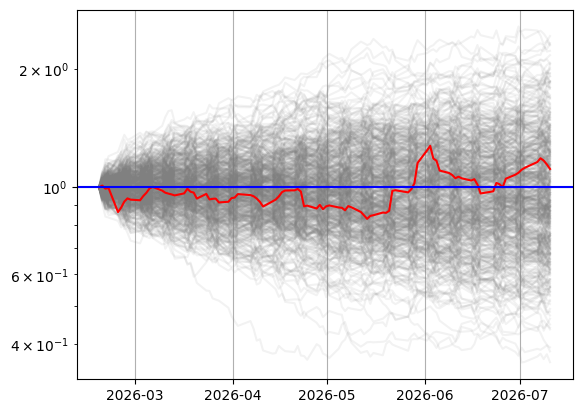

In [14]:
stock_GBM.simulate(n_paths=N_PATHS, time_horizon = len(x1) / 250) 
paths_GBM = stock_GBM.spot

plt.plot(data["Date"][T_start:],paths_GBM[0:500].T,alpha=0.1,color="grey")
plt.plot(data["Date"][T_start:],historical_prices_normalized,color="red")
plt.axhline(K,color="blue")
plt.yscale("log")
plt.grid()
paths_GBM.shape

{'pricer': None, 'cost': 0.0, '_clauses': OrderedDict(), '_underliers': OrderedDict([('underlier', BrownianStock(sigma=0.5201, dt=0.0040))]), 'call': True, 'strike': 1, 'maturity': 0.08}


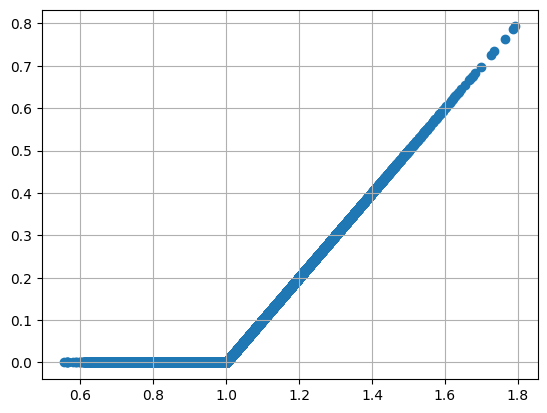

In [15]:
EuropeanCallOption = EuropeanOption(stock_GBM,strike=K,maturity=20/250)
derivative = EuropeanCallOption

print(EuropeanCallOption.__dict__)
EuropeanCallOption.simulate(N_PATHS) # Runs MonteCarlo simulation for the option
payoff = EuropeanCallOption.payoff_fn()
underlying = EuropeanCallOption.ul() # ul() returns the underlying asset
terminal_prices = underlying.spot[:, -1]  # Simulated prices at expiration
plt.scatter(terminal_prices, payoff)
plt.grid()

In [16]:
def fourier_features(log_path, K=3):
    # Compute only the requested coefficients, avoiding a full FFT.
    window = log_path.shape[-1]
    sample = torch.arange(window, device=log_path.device, dtype=log_path.dtype)
    frequency = torch.arange(K + 1, device=log_path.device, dtype=log_path.dtype)
    angle = 2 * torch.pi * frequency[:, None] * sample[None, :] / window
    scale = window ** -0.5

    real = scale * torch.einsum("...w,kw->...k", log_path, torch.cos(angle))
    imag = -scale * torch.einsum("...w,kw->...k", log_path, torch.sin(angle))

    return torch.cat([real[..., :1], real[..., 1:], imag[..., 1:]], dim=-1)


class RollingFourierFeature(StateIndependentFeature):
    def __init__(self, history_prices, K=3):
        super().__init__()

        history = torch.as_tensor(
            np.asarray(history_prices),
            dtype=torch.get_default_dtype(),
        )

        if history.ndim != 1:
            raise ValueError("history_prices must be one-dimensional")

        if history.numel() != 100:
            raise ValueError(
                f"Expected 100 historical prices, received {history.numel()}"
            )

        if torch.any(history <= 0):
            raise ValueError("history_prices must be positive")

        self.history_log_relative = torch.log(history / history[-1])
        self.window = history.numel()
        self.K = K

        if K >= self.window // 2 + 1:
            raise ValueError("K is too large for the history window")

    def __str__(self):
        return f"rolling_fourier_{self.K}"

    def get(self, time_step=None):
        spot = self.derivative.ul().spot
        log_spot = torch.log(spot)

        history = self.history_log_relative.to(spot)
        log_strike = spot.new_tensor(self.derivative.strike).log()

        # Align historical data so its final value equals simulated S_0
        historical_log_moneyness = (
            history[:-1].unsqueeze(0)
            + log_spot[:, :1]
            - log_strike
        )

        simulated_log_moneyness = log_spot - log_strike

        complete_path = torch.cat(
            [
                historical_log_moneyness.expand(spot.shape[0], -1),
                simulated_log_moneyness,
            ],
            dim=1,
        )

        # Shape: (n_paths, n_times, history_window)
        rolling_windows = complete_path.unfold(
            dimension=1,
            size=self.window,
            step=1,
        )

        features = fourier_features(
            rolling_windows,
            K=self.K,
        )

        if time_step is not None:
            features = features[:, time_step:time_step + 1, :]

        return features

In [17]:
K = 3
fourier_feature = RollingFourierFeature(
    history_prices=historical_prices.to_numpy(copy=True),
    K=K,
)

model1f = MultiLayerPerceptron(
    in_features=1 + 2 * K,
    n_units=16,
    n_layers=3,
)

hedger1f = Hedger(
    model1f,
    inputs=[fourier_feature],
)

print(hedger1f)
print(hedger1f.model)

Hedger(
  inputs=['rolling_fourier_3']
  (model): MultiLayerPerceptron(
    (0): Linear(in_features=7, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Identity()
  )
  (criterion): EntropicRiskMeasure()
)
MultiLayerPerceptron(
  (0): Linear(in_features=7, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=16, bias=True)
  (5): ReLU()
  (6): Linear(in_features=16, out_features=1, bias=True)
  (7): Identity()
)


In [18]:
model1 = MultiLayerPerceptron(
    in_features=3,
    n_units=16,
    n_layers=3,
)




hedger1 = Hedger(model1, inputs=["log_moneyness", "expiry_time", "volatility"])

print(hedger1)
print(hedger1.model)

Hedger(
  inputs=['log_moneyness', 'expiry_time', 'volatility']
  (model): MultiLayerPerceptron(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Identity()
  )
  (criterion): EntropicRiskMeasure()
)
MultiLayerPerceptron(
  (0): Linear(in_features=3, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=16, bias=True)
  (5): ReLU()
  (6): Linear(in_features=16, out_features=1, bias=True)
  (7): Identity()
)


In [19]:
class IndependentNets(nn.Module):
    def __init__(self, N):
        super().__init__()
        self.nets = nn.ModuleList([
            MultiLayerPerceptron(
                in_features=3,
                n_units=16,
                n_layers=3,
            )
            for _ in range(N)
        ])

    def forward(self, x):
        # x has shape (n_paths, N + 1, 3)
        outputs = [
            net(x[..., i:i + 1, :])
            for i, net in enumerate(self.nets)
        ]

        # PFHedge expects an output at maturity too
        return torch.cat(outputs + [outputs[-1]], dim=-2)


N = derivative.ul().spot.shape[-1] - 1

modelN = IndependentNets(N)

hedgerN = Hedger(
    modelN,
    inputs=["log_moneyness", "expiry_time", "volatility"],
)

print(hedgerN)
print(hedgerN.model)

Hedger(
  inputs=['log_moneyness', 'expiry_time', 'volatility']
  (model): IndependentNets(
    (nets): ModuleList(
      (0-19): 20 x MultiLayerPerceptron(
        (0): Linear(in_features=3, out_features=16, bias=True)
        (1): ReLU()
        (2): Linear(in_features=16, out_features=16, bias=True)
        (3): ReLU()
        (4): Linear(in_features=16, out_features=16, bias=True)
        (5): ReLU()
        (6): Linear(in_features=16, out_features=1, bias=True)
        (7): Identity()
      )
    )
  )
  (criterion): EntropicRiskMeasure()
)
IndependentNets(
  (nets): ModuleList(
    (0-19): 20 x MultiLayerPerceptron(
      (0): Linear(in_features=3, out_features=16, bias=True)
      (1): ReLU()
      (2): Linear(in_features=16, out_features=16, bias=True)
      (3): ReLU()
      (4): Linear(in_features=16, out_features=16, bias=True)
      (5): ReLU()
      (6): Linear(in_features=16, out_features=1, bias=True)
      (7): Identity()
    )
  )
)


In [20]:
history1 = hedger1.fit(derivative, n_epochs=N_EPOCHS, n_paths=N_PATHS,n_times=5)

Loss=0.0595: 100%|██████████| 100/100 [00:36<00:00,  2.76it/s]


In [21]:
historyN = hedgerN.fit(derivative, n_epochs=N_EPOCHS, n_paths=N_PATHS,n_times=5)

Loss=0.0597: 100%|██████████| 100/100 [00:46<00:00,  2.16it/s]


In [22]:
historyf = hedger1f.fit(derivative, n_epochs=N_EPOCHS, n_paths=N_PATHS,n_times=5)

Loss=0.0596: 100%|██████████| 100/100 [01:29<00:00,  1.11it/s]


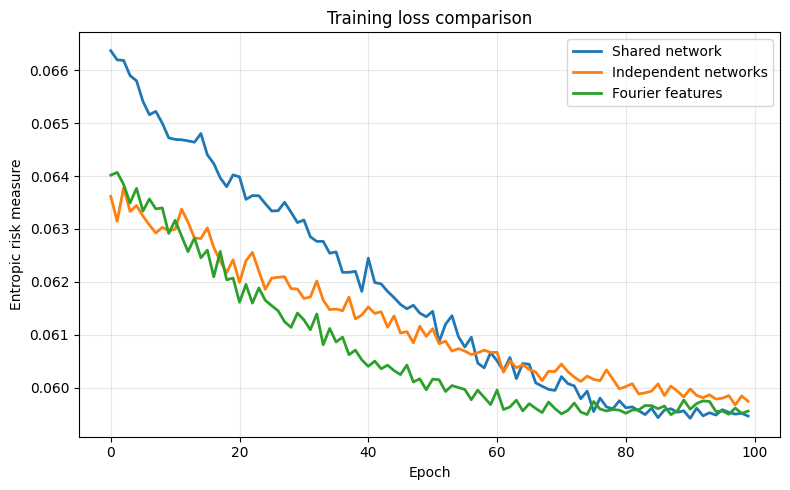

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(history1, label="Shared network", linewidth=2)
plt.plot(historyN, label="Independent networks", linewidth=2)
plt.plot(historyf, label="Fourier features", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Entropic risk measure")
plt.title("Training loss comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
def to_numpy(tensor: torch.Tensor) -> np.array:
    return tensor.detach().numpy()

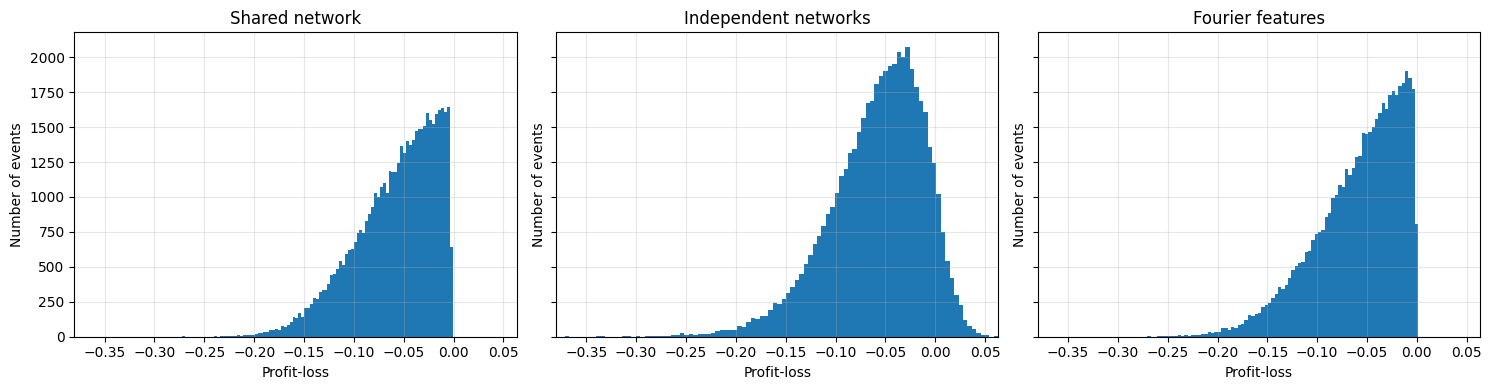

In [25]:
with torch.no_grad():
    pnl1 = hedger1.compute_pl(derivative).cpu()
    pnlN = hedgerN.compute_pl(derivative).cpu()
    pnlf = hedger1f.compute_pl(derivative).cpu()

all_pnl = torch.cat([pnl1, pnlN, pnlf])

xmin = all_pnl.min().item()
xmax = all_pnl.max().item()

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 4),
    sharex=True,
    sharey=True,
)

plots = [
    (pnl1, "Shared network"),
    (pnlN, "Independent networks"),
    (pnlf, "Fourier features"),
]

for ax, (pnl, title) in zip(axes, plots):
    ax.hist(pnl.numpy(), bins=100)
    ax.set_xlim(xmin, xmax)
    ax.set_title(title)
    ax.set_xlabel("Profit-loss")
    ax.set_ylabel("Number of events")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
model_ann = BlackScholes(derivative)
hedger_ann = Hedger(model_ann, inputs=model_ann.inputs())

price_bs = hedger_ann.price(derivative, n_paths=N_PATHS)
price1 = hedger1.price(derivative, n_paths=N_PATHS)
priceN = hedgerN.price(derivative, n_paths=N_PATHS)
pricef = hedger1f.price(derivative, n_paths=N_PATHS)

print(f"Black-Scholes price*:       {price_bs.item():.6f}")
print(f"Shared network price:       {price1.item():.6f}")
print(f"Independent networks price: {priceN.item():.6f}")
print(f"Fourier features price:     {pricef.item():.6f}")

Black-Scholes price*:       0.058666
Shared network price:       0.059514
Independent networks price: 0.059931
Fourier features price:     0.059231


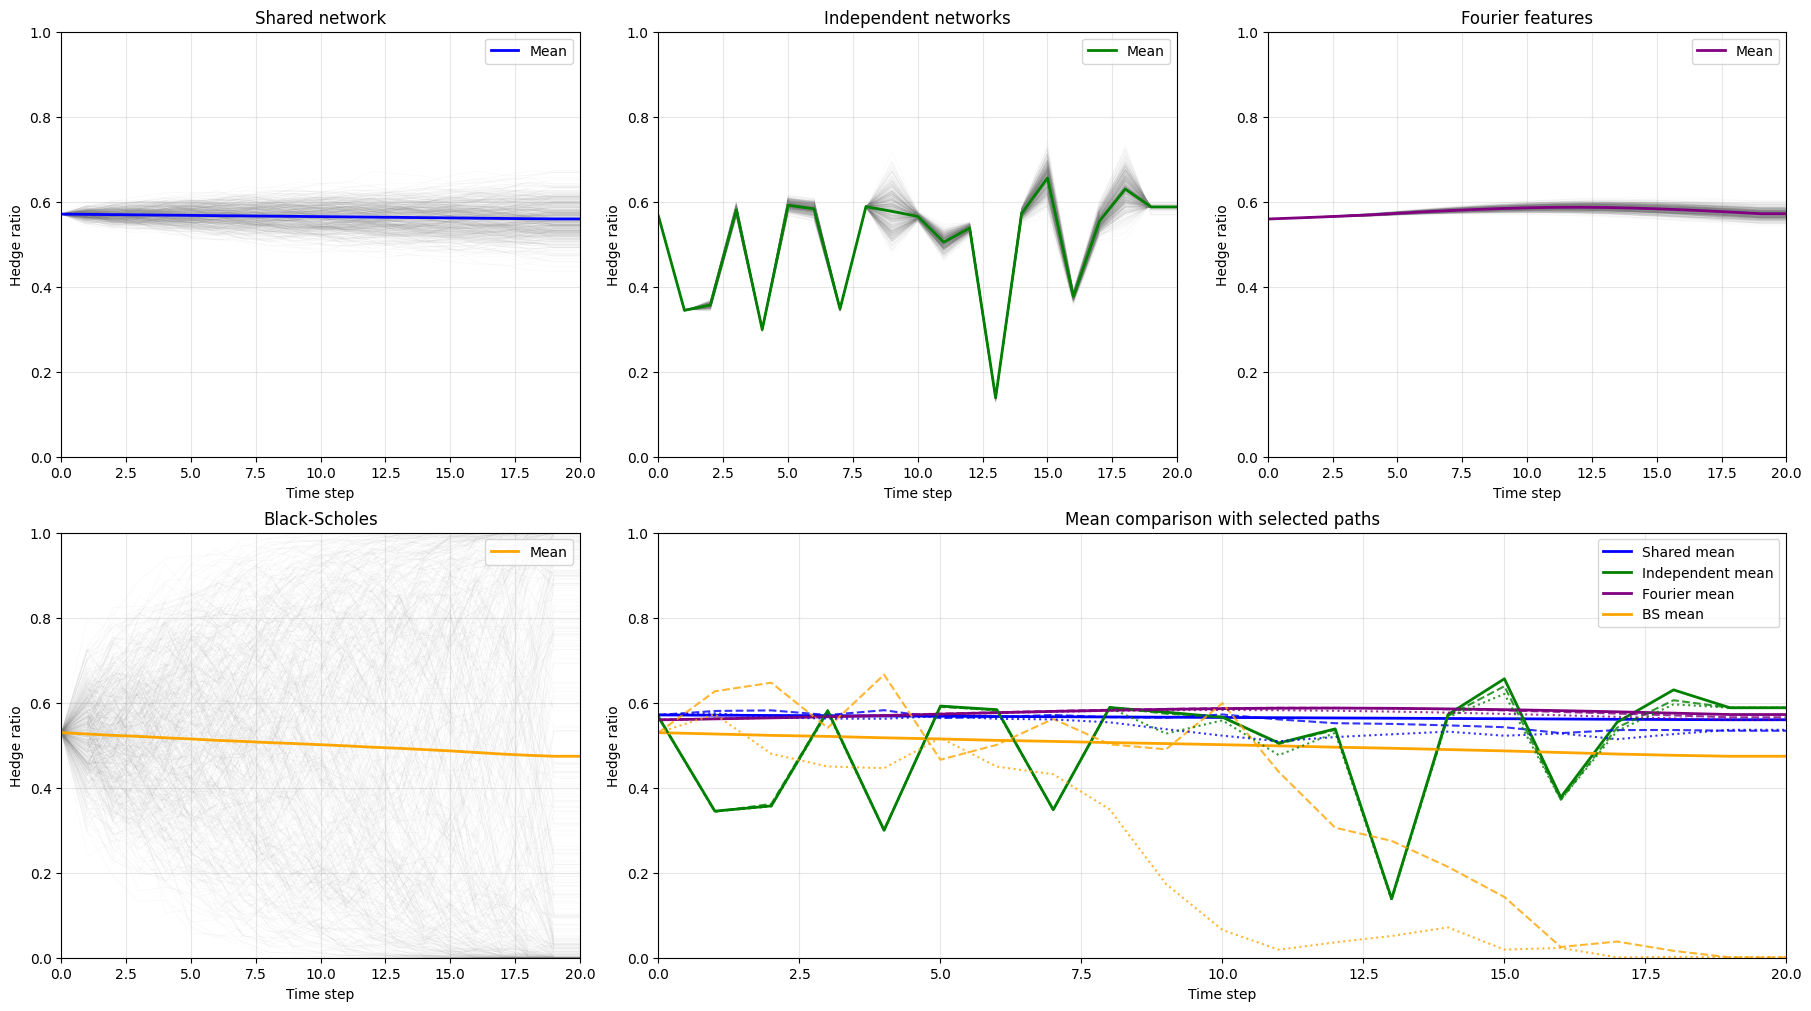

In [31]:
with torch.no_grad():
    delta_nn = hedger1.compute_hedge(derivative)[:, 0, :].cpu()
    delta_ind = hedgerN.compute_hedge(derivative)[:, 0, :].cpu()
    delta_f = hedger1f.compute_hedge(derivative)[:, 0, :].cpu()
    delta_bs = hedger_ann.compute_hedge(derivative)[:, 0, :].cpu()

time = np.arange(delta_nn.shape[1])
N_PLOT = 500

mean_nn = delta_nn.mean(dim=0)
mean_ind = delta_ind.mean(dim=0)
mean_f = delta_f.mean(dim=0)
mean_bs = delta_bs.mean(dim=0)

all_deltas = torch.cat([delta_nn, delta_ind, delta_f, delta_bs])
ymin = all_deltas.min().item()
ymax = all_deltas.max().item()

fig = plt.figure(figsize=(18, 10), constrained_layout=True)
gs = fig.add_gridspec(2, 3)

ax_ref = fig.add_subplot(gs[0, 0])

axes = [
    ax_ref,
    fig.add_subplot(gs[0, 1], sharex=ax_ref, sharey=ax_ref),
    fig.add_subplot(gs[0, 2], sharex=ax_ref, sharey=ax_ref),
    fig.add_subplot(gs[1, 0], sharex=ax_ref, sharey=ax_ref),
    fig.add_subplot(gs[1, 1:], sharex=ax_ref, sharey=ax_ref),
]

models = [
    (delta_nn, mean_nn, "Shared network", "blue"),
    (delta_ind, mean_ind, "Independent networks", "green"),
    (delta_f, mean_f, "Fourier features", "purple"),
    (delta_bs, mean_bs, "Black-Scholes", "orange"),
]

def plot_paths(ax, deltas, mean, title, color):
    for path in deltas[:N_PLOT]:
        ax.plot(
            time,
            path,
            color="gray",
            alpha=0.05,
            linewidth=0.5,
        )

    ax.plot(
        time,
        mean,
        color=color,
        linewidth=2,
        label="Mean",
    )

    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right")

for ax, model in zip(axes[:4], models):
    plot_paths(ax, *model)

# Mean comparison
ax = axes[4]

means = [
    (mean_nn, "blue", "Shared mean"),
    (mean_ind, "green", "Independent mean"),
    (mean_f, "purple", "Fourier mean"),
    (mean_bs, "orange", "BS mean"),
]

for mean, color, label in means:
    ax.plot(time, mean, color=color, linewidth=2, label=label)

for path, style in zip([0, 1], ["--", ":"]):
    ax.plot(time, delta_nn[path], color="blue", linestyle=style, alpha=0.8)
    ax.plot(time, delta_ind[path], color="green", linestyle=style, alpha=0.8)
    ax.plot(time, delta_f[path], color="purple", linestyle=style, alpha=0.8)
    ax.plot(time, delta_bs[path], color="orange", linestyle=style, alpha=0.8)

ax.set_title("Mean comparison with selected paths")
ax.grid(alpha=0.3)
ax.legend(loc="upper right")

for ax in axes:
    ax.set_xlim(time[0], time[-1])
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("Time step")
    ax.set_ylabel("Hedge ratio")

plt.show()

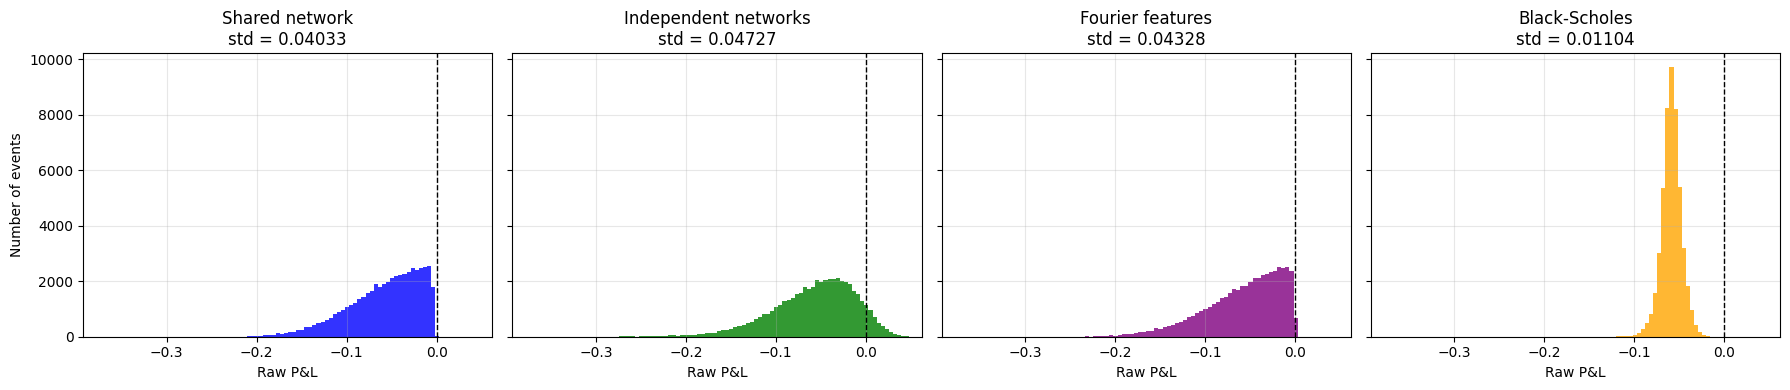

In [32]:
with torch.no_grad():
    pnl_nn = hedger1.compute_pl(derivative).cpu()
    pnl_ind = hedgerN.compute_pl(derivative).cpu()
    pnl_f = hedger1f.compute_pl(derivative).cpu()
    pnl_bs = hedger_ann.compute_pl(derivative).cpu()

all_pnl = torch.cat([pnl_nn, pnl_ind, pnl_f, pnl_bs])
xmin = all_pnl.min().item()
xmax = all_pnl.max().item()
bins = np.linspace(xmin, xmax, 101)

pnls = [
    (pnl_nn, "Shared network", "blue"),
    (pnl_ind, "Independent networks", "green"),
    (pnl_f, "Fourier features", "purple"),
    (pnl_bs, "Black-Scholes", "orange"),
]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(18, 4),
    sharex=True,
    sharey=True,
)

for ax, (pnl, label, color) in zip(axes, pnls):
    ax.hist(
        pnl.numpy(),
        bins=bins,
        color=color,
        alpha=0.8,
    )
    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1,
    )
    ax.set_xlim(xmin, xmax)
    ax.set_title(f"{label}\nstd = {pnl.std():.5f}")
    ax.set_xlabel("Raw P&L")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Number of events")

plt.tight_layout()
plt.show()

In [33]:
%pip install pysiglib

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/817.7 kB ? eta -:--:--
   ---------------------------------------- 817.7/817.7 kB 17.9 MB/s  0:00:00
  Created wheel for kauri: filename=kauri-2.3.0-py3-none-any.whl size=103517 sha256=3dd5f6d35d1965b53bece8038ac0471d2e98ee5125481d24cbf365d8d5da7fa7
  Stored in directory: c:\users\trist\appdata\local\pip\cache\wheels\de\bf\18\9d5347601a94fa173531bdb84122c9b381f20df74d6d5a490c
Successfully built kauri

   ---------------------------------------- 0/2 [kauri]
   ---------------------------------------- 0/2 [kauri]
   ---------------------------------------- 0/2 [kauri]
   ---------------------------------------- 0/2 [


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\trist\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
